Metadata shape: (1802, 30)

Columns:
['sample', 'cancer_type', 'bcr_patient_barcode', 'gender', 'race', 'ethnicity', 'age_at_diagnosis', 'ajcc_pathologic_tumor_stage', 'ajcc_nodes_pathologic_pn', 'ajcc_metastasis_pathologic_pm', 'ajcc_tumor_pathologic_pt', 'tumor_status', 'histologic_diagnosis', 'history_other_malignancy', 'history_thyroid_disease', 'history_thyroid_disease_other', 'history_reflux_disease_indicator', 'history_hormonal_contraceptives_use', 'pregnancies_count_miscarriage', 'jewish_religion_heritage_indicator', 'tobacco_smoking_age_started', 'family_history_cancer_type', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time']

First 5 rows:
                         sample cancer_type bcr_patient_barcode  gender  \
0  TCGA-E9-A1NI-01A-11R-A14D-07        BRCA        TCGA-E9-A1NI  FEMALE   
1  TCGA-E2-A1LK-01A-21R-A14D-07        BRCA        TCGA-E2-A1LK  FEMALE   
2  TCGA-BH-A0B2-01A-11R-A10J-07        BRCA        TCGA-BH-A0B2  FEMALE   
3  TCGA-E2-A107-01A

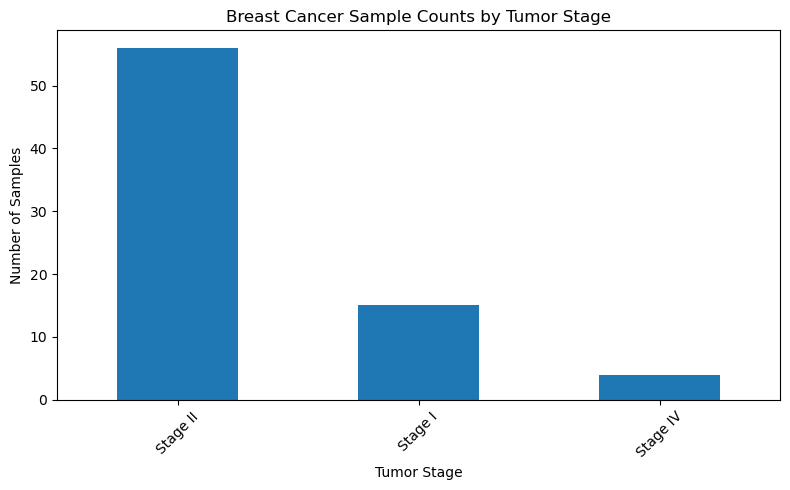

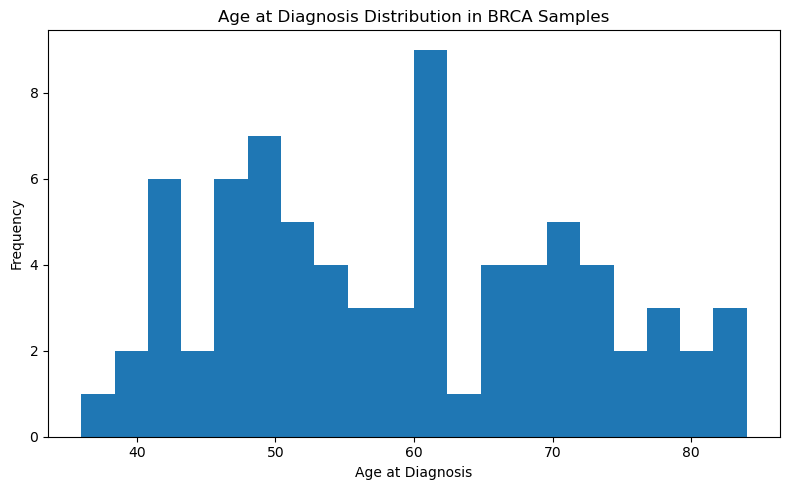

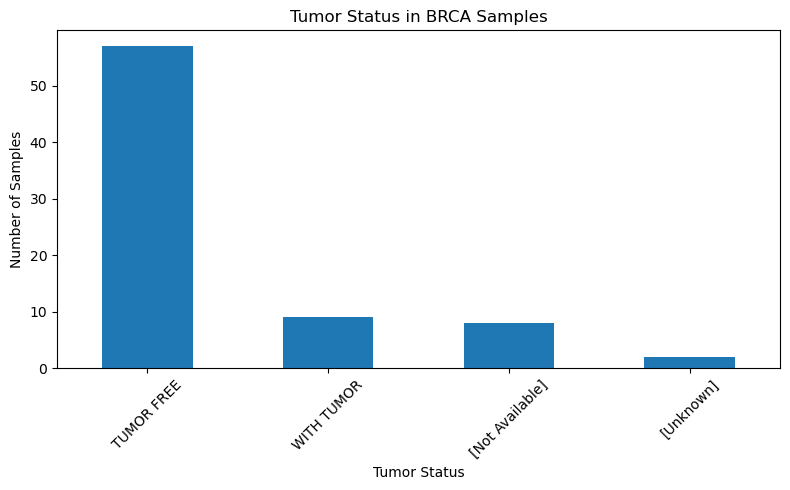

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training metadata only
metadata = pd.read_csv(r"/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/TRAINING_SET_GSE62944_metadata.csv")

# Basic overview
print("Metadata shape:", metadata.shape)
print("\nColumns:")
print(metadata.columns.tolist())

print("\nFirst 5 rows:")
print(metadata.head())

print("\nMissing values by column:")
print(metadata.isna().sum())

# Focus on breast cancer
brca_metadata = metadata[metadata["cancer_type"] == "BRCA"].copy()

print("\nBRCA metadata shape:", brca_metadata.shape)

# Convert age to numeric
brca_metadata["age_at_diagnosis"] = pd.to_numeric(
    brca_metadata["age_at_diagnosis"], errors="coerce"
)

print("\nBRCA gender counts:")
print(brca_metadata["gender"].value_counts(dropna=False))

print("\nBRCA tumor stage counts:")
print(brca_metadata["ajcc_pathologic_tumor_stage"].value_counts(dropna=False))

print("\nBRCA tumor status counts:")
print(brca_metadata["tumor_status"].value_counts(dropna=False))

print("\nBRCA average age at diagnosis:")
print(brca_metadata["age_at_diagnosis"].mean())

print("\nBRCA survival summary:")
survival_cols = ["OS", "OS.time", "DSS", "DSS.time", "DFI", "DFI.time", "PFI", "PFI.time"]
for col in survival_cols:
    if col in brca_metadata.columns:
        print(f"\n{col}")
        print(brca_metadata[col].describe())

# Simplify tumor stage
def simplify_stage(stage):
    if pd.isna(stage):
        return pd.NA
    stage = str(stage).upper()
    if "STAGE I" in stage and "II" not in stage and "III" not in stage and "IV" not in stage:
        return "Stage I"
    elif "STAGE II" in stage:
        return "Stage II"
    elif "STAGE III" in stage:
        return "Stage III"
    elif "STAGE IV" in stage:
        return "Stage IV"
    else:
        return pd.NA

brca_metadata["stage_simple"] = brca_metadata["ajcc_pathologic_tumor_stage"].apply(simplify_stage)

print("\nSimplified BRCA stage counts:")
print(brca_metadata["stage_simple"].value_counts(dropna=False))

# Plot 1: tumor stage distribution
plt.figure(figsize=(8, 5))
brca_metadata["stage_simple"].value_counts().plot(kind="bar")
plt.title("Breast Cancer Sample Counts by Tumor Stage")
plt.xlabel("Tumor Stage")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: age at diagnosis distribution
plt.figure(figsize=(8, 5))
brca_metadata["age_at_diagnosis"].dropna().plot(kind="hist", bins=20)
plt.title("Age at Diagnosis Distribution in BRCA Samples")
plt.xlabel("Age at Diagnosis")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Plot 3: tumor status distribution
plt.figure(figsize=(8, 5))
brca_metadata["tumor_status"].value_counts().plot(kind="bar")
plt.title("Tumor Status in BRCA Samples")
plt.xlabel("Tumor Status")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Exploratory data analysis (EDA) on a cancer dataset
# Loading the files and exploring the data with pandas
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# %%
# Load the data
####################################################
metadata_df  = pd.read_csv(
    '/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)  # can also use larger dataset with more genes
data= pd.read_csv(
    '/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
print(data.head())

# %%
# Explore the data
####################################################
print(data.shape)
print(data.info())
print(data.describe())

# %%
# Explore the metadata
####################################################
print(metadata_df.info())
print(metadata_df.describe())

# %%
# Subset the data for a specific cancer type
####################################################
cancer_type = 'BRCA'  # Breast Invasive Carcinoma

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
BRCA_data = data[cancer_samples]

# %%
# Subset by index (genes)
####################################################
desired_gene_list = [
    "TP53", "BAX", "BAK1", "BCL2", "BCL2L1", "MCL1",
    "BBC3", "PMAIP1", "BID", "BAD",
    "CASP3", "CASP7", "CASP8", "CASP9",
    "APAF1", "FAS", "FASLG",
    "XIAP", "BIRC5", "CYCS", "MDM2"
]

gene_list = [gene for gene in desired_gene_list if gene in BRCA_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
BRCA_gene_data = BRCA_data.loc[gene_list]
print(BRCA_gene_data.head())

# %%
# Basic statistics on the subsetted data
####################################################
print(BRCA_gene_data.describe())
print(BRCA_gene_data.var(axis=1))  # Variance of each gene across samples
# Mean expression of each gene across samples
print(BRCA_gene_data.mean(axis=1))
# Median expression of each gene across samples
print(BRCA_gene_data.median(axis=1))

# %%
# Explore categorical variables in metadata
####################################################
# groupby allows you to group on a specific column in the dataset,
# and then print out summary stats or counts for other columns within those groups
print(metadata_df.groupby('cancer_type')["gender"].value_counts())

# Explore average age at diagnosis by cancer type
metadata_df['age_at_diagnosis'] = pd.to_numeric(
    metadata_df['age_at_diagnosis'], errors='coerce')
print(metadata_df.groupby(
    'cancer_type')["age_at_diagnosis"].mean())
# %%
# Merging datasets
####################################################
# Merge the subsetted expression data with metadata for BRCA samples,
# so rows are samples and columns include gene expression for EGFR and MYC and metadata
BRCA_metadata = metadata_df.loc[cancer_samples]
BRCA_merged = BRCA_gene_data.T.merge(
    BRCA_metadata, left_index=True, right_index=True)
print(BRCA_merged.head())




        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG                        3.789771                      3.967578   
A1CF                        0.065051                      0.000000   
A2M                         9.024479                      7.573842   
A2ML1                       0.428689                      0.465410   
A4GALT                      4.072650                      4.208381   

        TCGA-LL-A5YN-01A-11R-A28M-07  TCGA-BH-A0DQ-01A-11R-A084-07  \
A1BG                        4.733007                      3.011343   
A1CF              

/var/folders/sh/jjkbvgl50ng8q9byqgv31ylr0000gn/T/ipykernel_8017/3087755909.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=X_pca[:, 0],
/var/folders/sh/jjkbvgl50ng8q9byqgv31ylr0000gn/T/ipykernel_8017/3087755909.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Species")


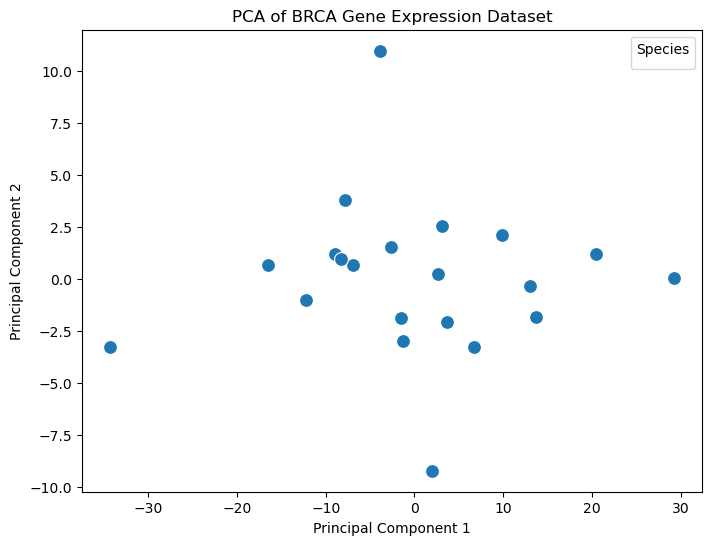

In [21]:
X = BRCA_gene_data

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0],
                y=X_pca[:, 1], 
                palette="Set2",
                s=100)
plt.title("PCA of BRCA Gene Expression Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Species")
plt.show()